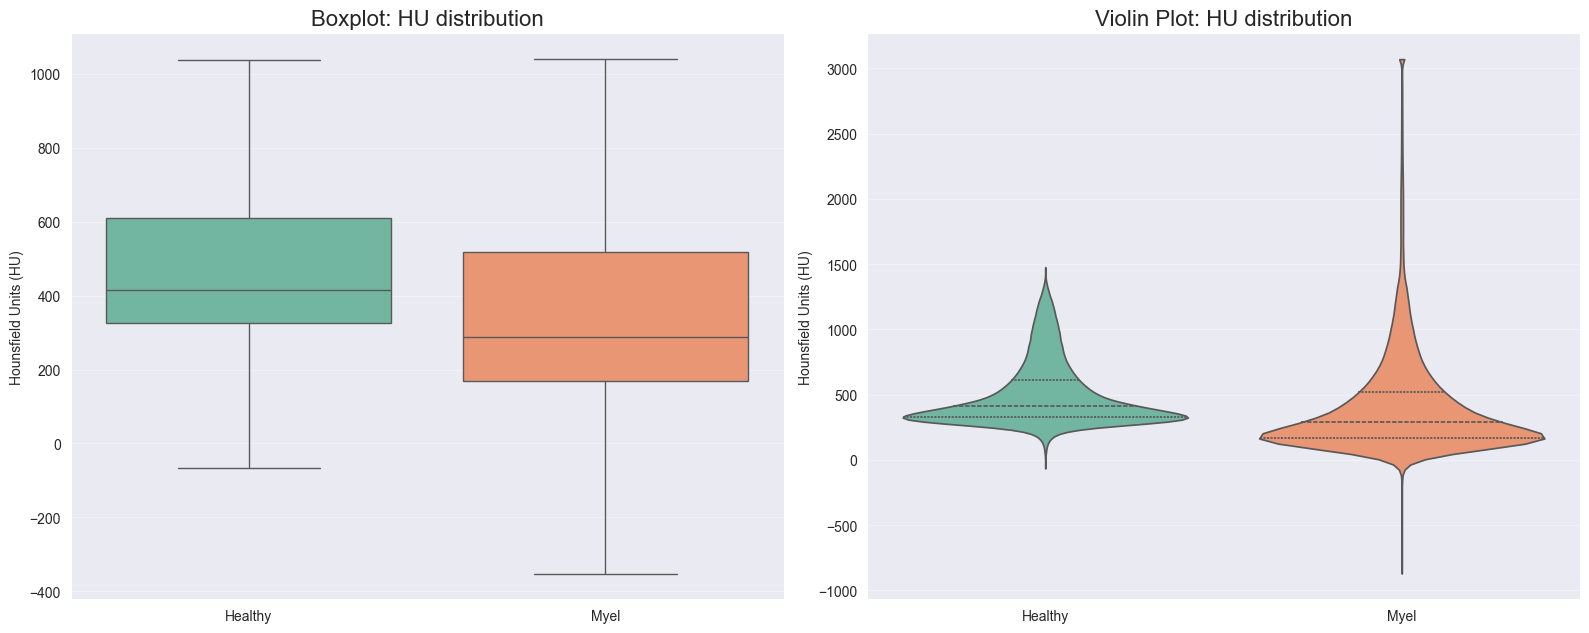

In [3]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns


def get_roi_values(img_path, mask_path):
    img = nib.load(img_path)
    mask = nib.load(mask_path)
    img_data = img.get_fdata()
    mask_data = mask.get_fdata()
    roi_values = img_data[mask_data > 0]
    return roi_values

# Konfigurácia ciest
data_config = [
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_spine_seg.nii.gz",
     "label": "Healthy"},
    {"img": r"E:\DATA_Myelomy\Myel_001\myel_001_konv.nii.gz",
     "mask": r"E:\DATA_Myelomy\Myel_001\myel_001_spine_seg.nii.gz",
     "label": "Myel"}
]

all_values = []
labels = []

for p in data_config:
    values = get_roi_values(p['img'], p['mask'])
    all_values.append(values)
    labels.append(p['label'])

# --- VIZUALIZÁCIA (Boxplot a Violin Plot vedľa seba) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("darkgrid")

# 1. BOXPLOT (vľavo)
sns.boxplot(ax=ax1, data=all_values, showfliers=False, palette="Set2")
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels)
ax1.set_title('Boxplot: HU distribution', fontsize=16)
ax1.set_ylabel('Hounsfield Units (HU)')
# ax1.axhline(0, color='red', linestyle='--', alpha=0.5)

# 2. VIOLIN PLOT (vpravo)
sns.violinplot(ax=ax2, data=all_values, inner="quartile", palette="Set2", cut=0)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_title('Violin Plot: HU distribution', fontsize=16)
ax2.set_ylabel('Hounsfield Units (HU)')
# ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

# plt.suptitle('Analýza ROI vertebrae: Healthy vs Myeloma', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Healthy percentile10 = -125.0
Healthy percentile10 = -131.0


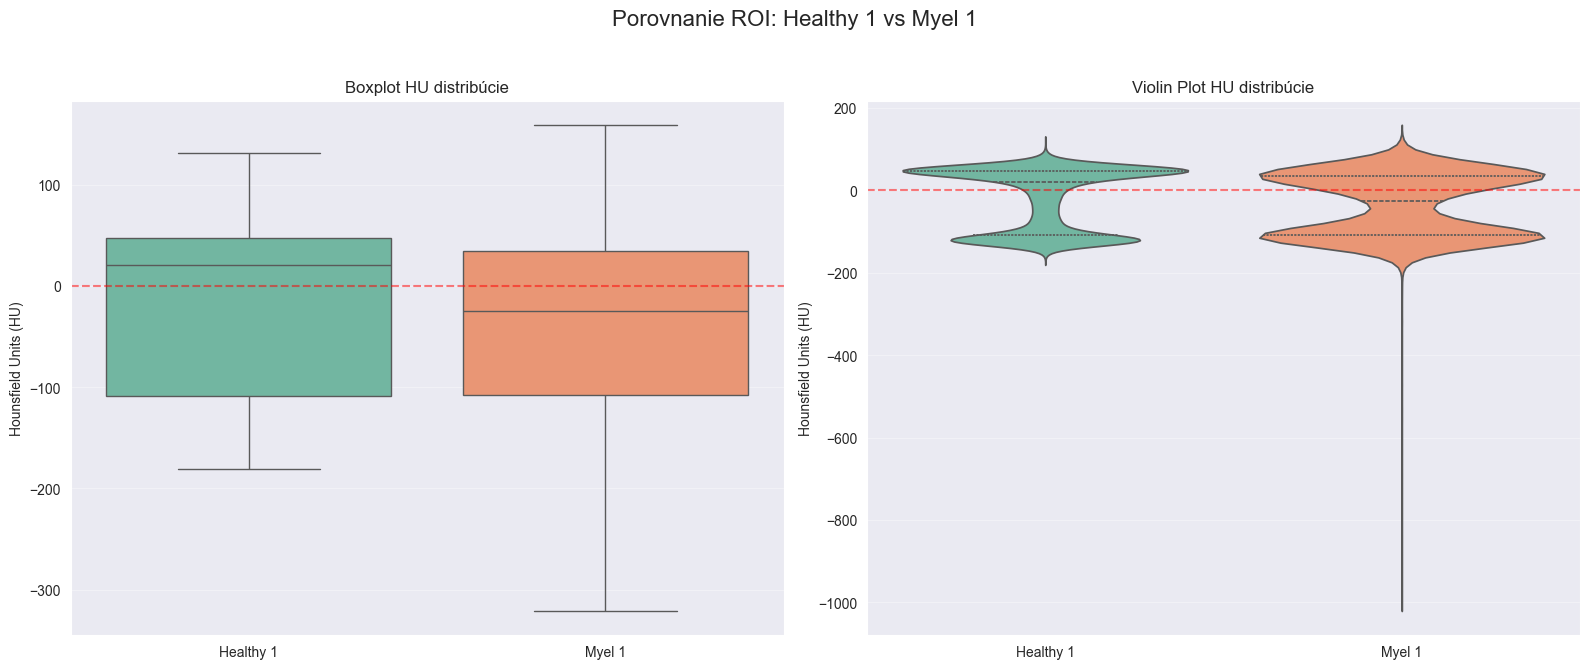

In [10]:
%matplotlib qt
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import time

def visualize_dual_sync(p1_cfg, p2_cfg):
    # 1. Načítanie oboch obrazov
    img1 = nib.load(p1_cfg['img']).get_fdata()
    img2 = nib.load(p2_cfg['img']).get_fdata()

    # Vytvorenie jednej figúry s dvoma podgrafmi (1 riadok, 2 stĺpce)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Nastavenie okna pre zobrazenie (Bone window pre spine)
    vmin, vmax = -200, 800

    # Určíme dĺžku animácie podľa toho, ktorý rozsah je kratší
    z_len1 = p1_cfg['z_range'][1] - p1_cfg['z_range'][0]
    z_len2 = p2_cfg['z_range'][1] - p2_cfg['z_range'][0]
    num_frames = min(z_len1, z_len2)

    plt.show(block=False)

    for i in range(num_frames):
        # Aktuálne indexy rezov pre každého pacienta
        z1 = p1_cfg['z_range'][0] + i
        z2 = p2_cfg['z_range'][0] + i

        # --- Pacient 1 (Vľavo) ---
        ax1.clear()
        ax1.imshow(img1[:, :, z1].T, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
        rect1 = plt.Rectangle((p1_cfg['x_range'][0], p1_cfg['y_range'][0]),
                              p1_cfg['x_range'][1]-p1_cfg['x_range'][0],
                              p1_cfg['y_range'][1]-p1_cfg['y_range'][0],
                              linewidth=2, edgecolor='green', facecolor='none')
        ax1.add_patch(rect1)
        ax1.set_title(f"{p1_cfg['label']} | Rez: {z1}")
        ax1.axis('on')

        # --- Pacient 2 (Vpravo) ---
        ax2.clear()
        ax2.imshow(img2[:, :, z2].T, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
        rect2 = plt.Rectangle((p2_cfg['x_range'][0], p2_cfg['y_range'][0]),
                              p2_cfg['x_range'][1]-p2_cfg['x_range'][0],
                              p2_cfg['y_range'][1]-p2_cfg['y_range'][0],
                              linewidth=2, edgecolor='red', facecolor='none')
        ax2.add_patch(rect2)
        ax2.set_title(f"{p2_cfg['label']} | Rez: {z2}")
        ax2.axis('on')

        # Prekreslenie spoločného okna
        fig.canvas.draw()
        fig.canvas.flush_events()
        time.sleep(0.05)

    plt.close(fig)

    # Extrakcia hodnôt pre boxplot (z celého 3D rozsahu)
    vals1 = img1[p1_cfg['x_range'][0]:p1_cfg['x_range'][1],
                 p1_cfg['y_range'][0]:p1_cfg['y_range'][1],
                 p1_cfg['z_range'][0]:p1_cfg['z_range'][1]].flatten()
    print(f"Healthy percentile10 = {np.percentile(vals1, 10)}")

    vals2 = img2[p2_cfg['x_range'][0]:p2_cfg['x_range'][1],
                 p2_cfg['y_range'][0]:p2_cfg['y_range'][1],
                 p2_cfg['z_range'][0]:p2_cfg['z_range'][1]].flatten()
    print(f"Healthy percentile10 = {np.percentile(vals2, 10)}")

    return vals1, vals2

# --- KONFIGURÁCIA ---
p1_config = {
    "img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_001\healthy_001_konv.nii.gz",
    "label": "Healthy 1",
    "x_range": (25, 50), "y_range": (200, 225), "z_range": (100, 300)
}

p2_config = {
    "img": r"E:\DATA_Myelomy\Myel_001\myel_001_konv.nii.gz",
    "label": "Myel 1",
    "x_range": (75, 100), "y_range": (200, 225), "z_range": (550, 750)
}

# Spustenie vizualizácie (otvorí QT/TK okno s videom)
v1, v2 = visualize_dual_sync(p1_config, p2_config)

# --- FINÁLNA VIZUALIZÁCIA (Boxplot + Violin Plot) ---
import seaborn as sns
import numpy as np

sns.set_style("darkgrid")
# Prepnutie späť do notebooku
%matplotlib inline

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
labels = [p1_config['label'], p2_config['label']]
all_data = [v1, v2]

# 1. BOXPLOT
sns.boxplot(ax=ax1, data=all_data, showfliers=False, palette="Set2")
ax1.set_xticks([0, 1])
ax1.set_xticklabels(labels)
ax1.set_ylabel('Hounsfield Units (HU)')
ax1.set_title('Boxplot HU distribúcie')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)

# 2. VIOLIN PLOT
sns.violinplot(ax=ax2, data=all_data, inner="quartile", palette="Set2", cut=0)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(labels)
ax2.set_ylabel('Hounsfield Units (HU)')
ax2.set_title('Violin Plot HU distribúcie')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle(f'Porovnanie ROI: {p1_config["label"]} vs {p2_config["label"]}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Healthy 10 - 10th Percentile: 12.00
Myel 1 - 10th Percentile: -12.00


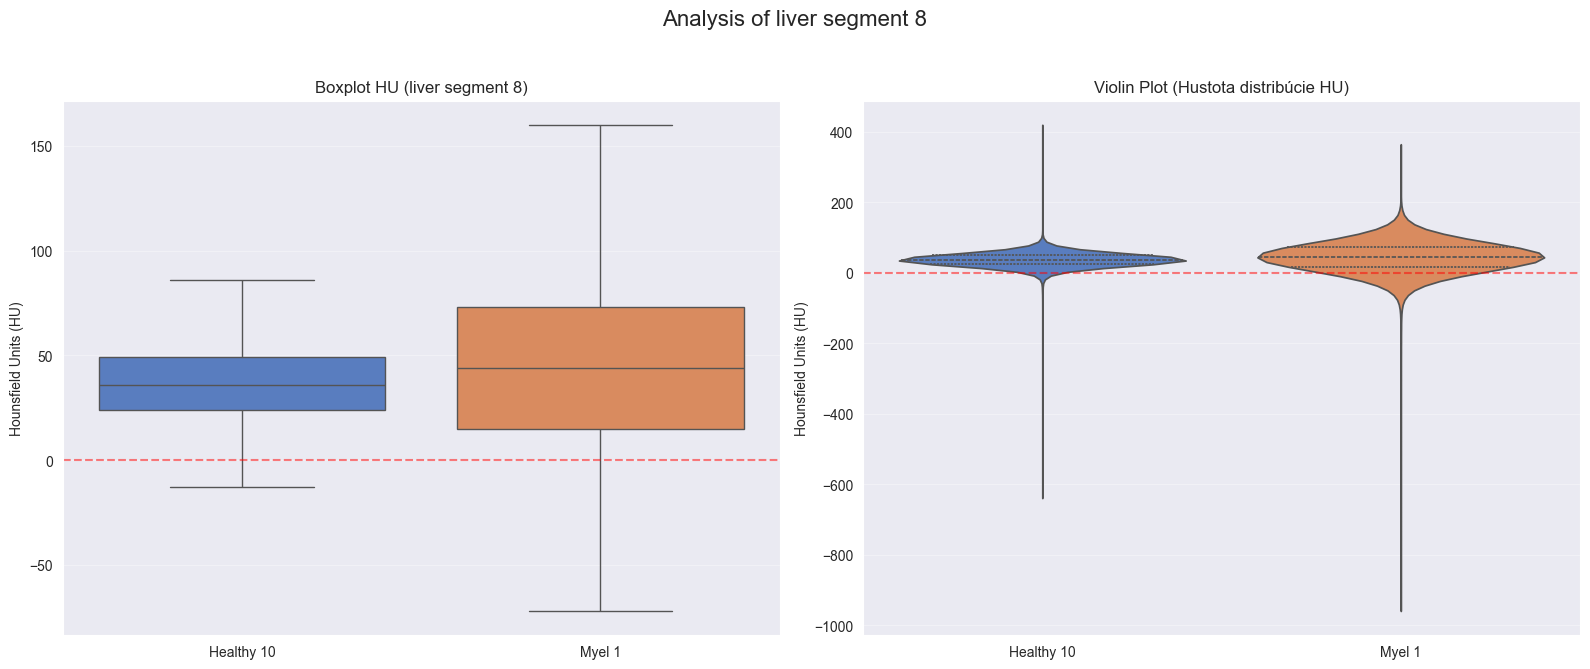

In [13]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns


def get_roi_values(img_path, mask_path):
    # Načítanie CT obrazu a masky
    img = nib.load(img_path)
    mask = nib.load(mask_path)

    img_data = img.get_fdata()
    mask_data = mask.get_fdata()

    # Extrakcia HU hodnôt tam, kde je maska aktívna
    roi_values = img_data[mask_data > 0]

    # Výpočet 10. percentilu
    p10 = np.percentile(roi_values, 10) if len(roi_values) > 0 else np.nan
    return roi_values, p10

# Konfigurácia ciest
data_config = [
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\liver_segment_8.nii.gz",
     "label": "Healthy 10"},
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_001\myel_001_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_001\liver_segment_8.nii.gz",
     "label": "Myel 1"}
]

all_values = []
p10_stats = []
labels = []

# Spracovanie dát
for p in data_config:
    values, p10 = get_roi_values(p['img'], p['mask'])
    all_values.append(values)
    p10_stats.append(p10)
    labels.append(p['label'])
    print(f"{p['label']} - 10th Percentile: {p10:.2f}")

# --- VIZUALIZÁCIA ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("darkgrid")

# 1. Boxplot (vľavo)
sns.boxplot(ax=ax1, data=all_values, showfliers=False, palette="muted")
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels)
ax1.set_title('Boxplot HU (liver segment 8)')
ax1.set_ylabel('Hounsfield Units (HU)')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)

# 2. Violin Plot (vpravo)
sns.violinplot(ax=ax2, data=all_values, inner="quartile", palette="muted", cut=0)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_title('Violin Plot (Hustota distribúcie HU)')
ax2.set_ylabel('Hounsfield Units (HU)')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Analysis of liver segment 8', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Healthy 10 - 10th Percentile: -133.00
Myel 3 - 10th Percentile: -141.00


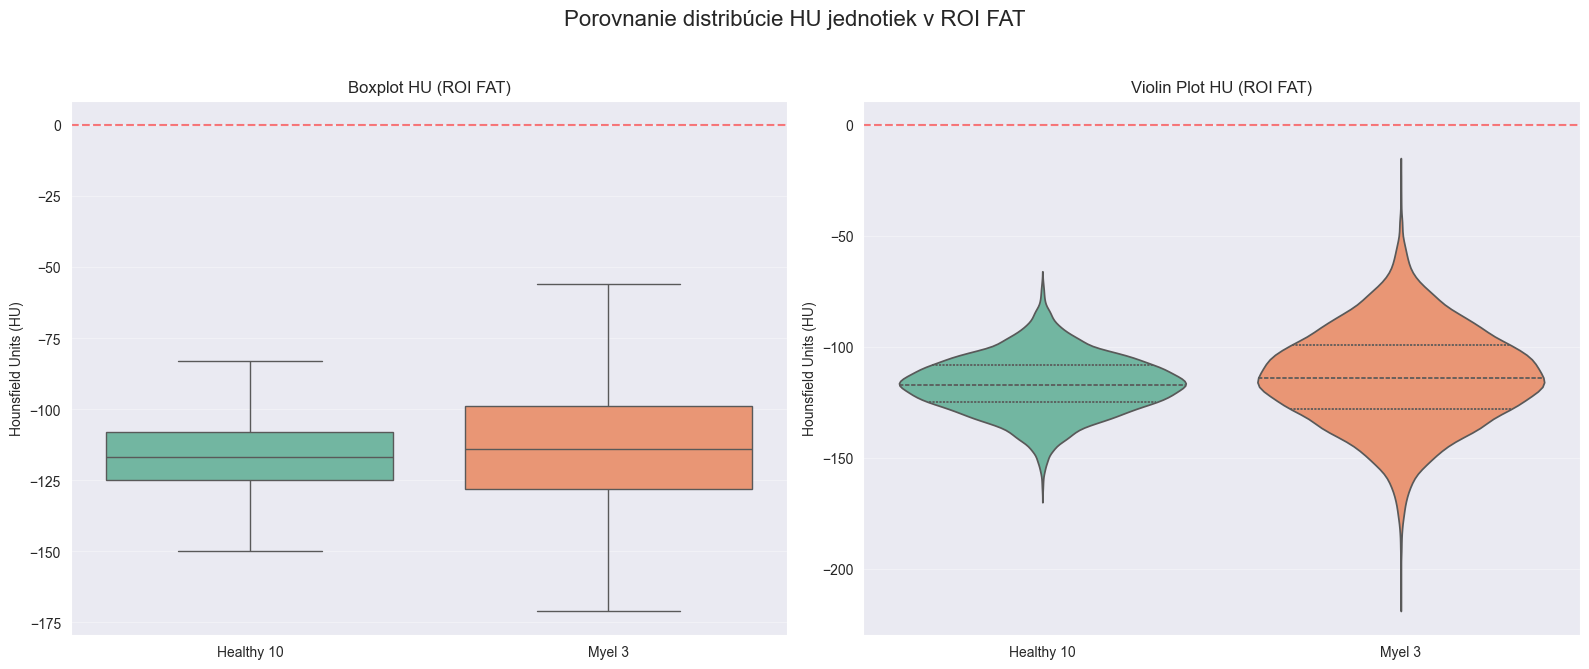

In [14]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns


def get_roi_values(img_path, mask_path):
    img = nib.load(img_path)
    mask = nib.load(mask_path)
    img_data = img.get_fdata()
    mask_data = mask.get_fdata()

    roi_values = img_data[mask_data > 0]

    p10 = np.percentile(roi_values, 10) if len(roi_values) > 0 else np.nan
    return roi_values, p10

# Cesty k tvojim súborom
data_config = [
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv_fat_segment.nii.gz",
     "label": "Healthy 10"},
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_003\myel_003_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_003\myel_003_konv_fat_segment.nii.gz",
     "label": "Myel 3"}
]

all_values = []
p10_stats = []
labels = []

for p in data_config:
    values, p10 = get_roi_values(p['img'], p['mask'])
    all_values.append(values)
    p10_stats.append(p10)
    labels.append(p['label'])

    print(f"{p['label']} - 10th Percentile: {p10:.2f}")

# --- VIZUALIZÁCIA (Subplots) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("darkgrid")

# 1. BOXPLOT (vľavo)
sns.boxplot(ax=ax1, data=all_values, showfliers=False, palette="Set2")
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels)
ax1.set_title('Boxplot HU (ROI FAT)')
ax1.set_ylabel('Hounsfield Units (HU)')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)

# 2. VIOLIN PLOT (vpravo)
sns.violinplot(ax=ax2, data=all_values, inner="quartile", palette="Set2", cut=0)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_title('Violin Plot HU (ROI FAT)')
ax2.set_ylabel('Hounsfield Units (HU)')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Porovnanie distribúcie HU jednotiek v ROI FAT', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Healthy - 10th Percentile: 42.00
Myel - 10th Percentile: 15.00


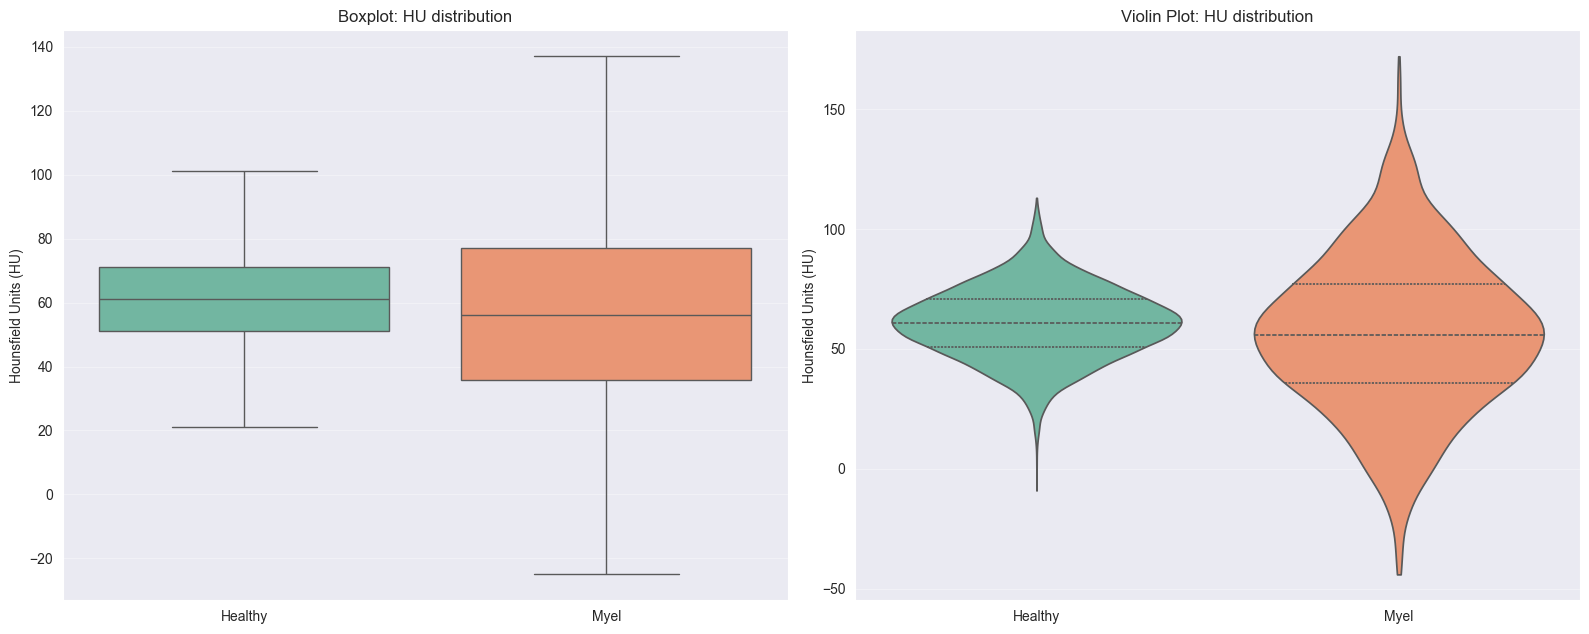

In [2]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns


def get_roi_values(img_path, mask_path):
    img = nib.load(img_path)
    mask = nib.load(mask_path)
    img_data = img.get_fdata()
    mask_data = mask.get_fdata()

    roi_values = img_data[mask_data > 0]

    p10 = np.percentile(roi_values, 10) if len(roi_values) > 0 else np.nan
    return roi_values, p10

# Cesty k tvojim súborom
data_config = [
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv_muscle_segment.nii.gz",
     "label": "Healthy"},
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_003\myel_003_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_003\myel_003_konv_muscle_segment.nii.gz",
     "label": "Myel"}
]

all_values = []
p10_stats = []
labels = []

for p in data_config:
    values, p10 = get_roi_values(p['img'], p['mask'])
    all_values.append(values)
    p10_stats.append(p10)
    labels.append(p['label'])

    print(f"{p['label']} - 10th Percentile: {p10:.2f}")

# --- VIZUALIZÁCIA (Subplots) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("darkgrid")

# 1. BOXPLOT (vľavo)
sns.boxplot(ax=ax1, data=all_values, showfliers=False, palette="Set2")
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels)
ax1.set_title('Boxplot: HU distribution')
ax1.set_ylabel('Hounsfield Units (HU)')
# ax1.axhline(0, color='red', linestyle='--', alpha=0.5)

# 2. VIOLIN PLOT (vpravo)
sns.violinplot(ax=ax2, data=all_values, inner="quartile", palette="Set2", cut=0)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_title('Violin Plot: HU distribution')
ax2.set_ylabel('Hounsfield Units (HU)')
# ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

# plt.suptitle('Porovnanie distribúcie HU jednotiek v ROI MUSCLE', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Healthy 10 - 10th Percentile: 32.00
Myel 3 - 10th Percentile: 1.00


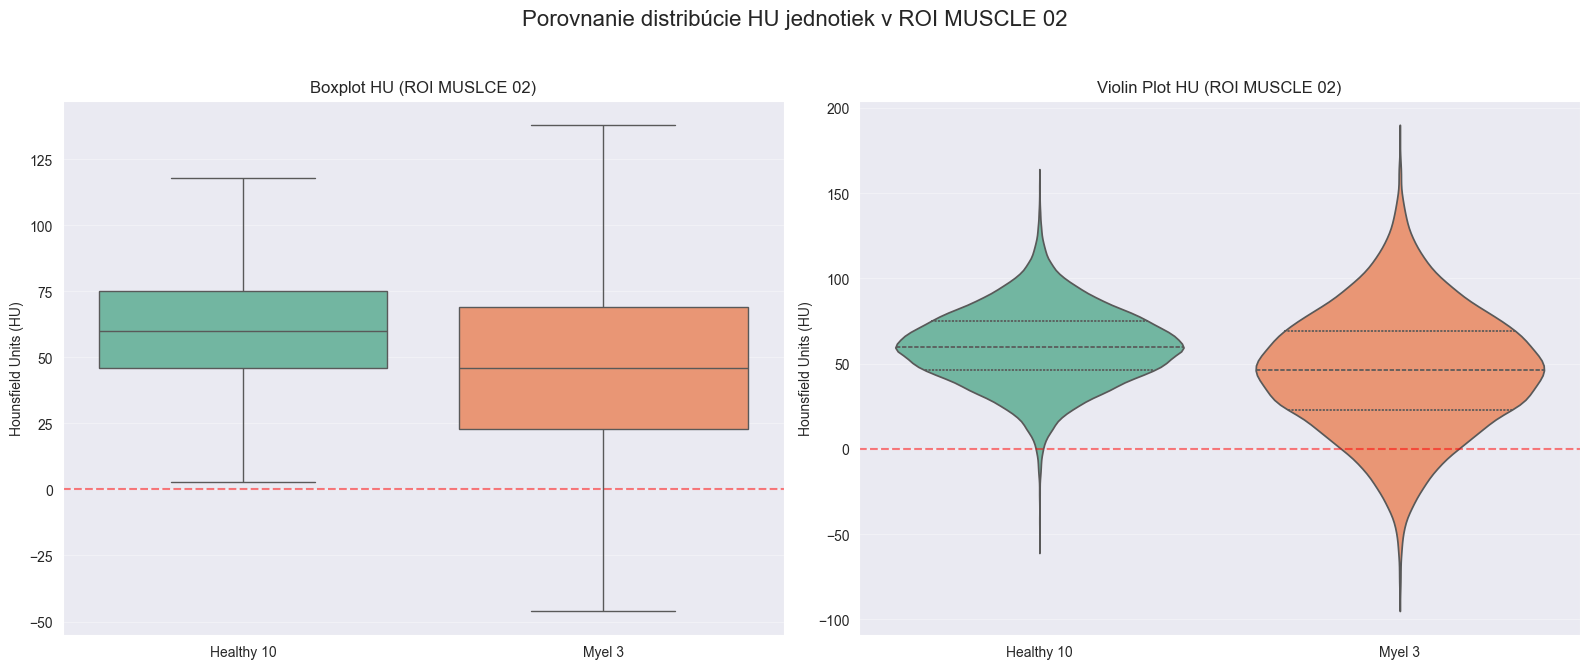

In [2]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns


def get_roi_values(img_path, mask_path):
    img = nib.load(img_path)
    mask = nib.load(mask_path)
    img_data = img.get_fdata()
    mask_data = mask.get_fdata()

    roi_values = img_data[mask_data > 0]

    p10 = np.percentile(roi_values, 10) if len(roi_values) > 0 else np.nan
    return roi_values, p10

# Cesty k tvojim súborom
data_config = [
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv_muscle02_segment.nii.gz",
     "label": "Healthy 10"},
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_003\myel_003_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_003\myel_003_konv_muscle02_segment.nii.gz",
     "label": "Myel 3"}
]

all_values = []
p10_stats = []
labels = []

for p in data_config:
    values, p10 = get_roi_values(p['img'], p['mask'])
    all_values.append(values)
    p10_stats.append(p10)
    labels.append(p['label'])

    print(f"{p['label']} - 10th Percentile: {p10:.2f}")

# --- VIZUALIZÁCIA (Subplots) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("darkgrid")

# 1. BOXPLOT (vľavo)
sns.boxplot(ax=ax1, data=all_values, showfliers=False, palette="Set2")
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels)
ax1.set_title('Boxplot HU (ROI MUSLCE 02)')
ax1.set_ylabel('Hounsfield Units (HU)')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)

# 2. VIOLIN PLOT (vpravo)
sns.violinplot(ax=ax2, data=all_values, inner="quartile", palette="Set2", cut=0)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_title('Violin Plot HU (ROI MUSCLE 02)')
ax2.set_ylabel('Hounsfield Units (HU)')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Porovnanie distribúcie HU jednotiek v ROI MUSCLE 02', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Trying extract percentile10 on resampled images

HEALTHY -> Percentile10: 51.00
MM -> Percentile10: 44.00


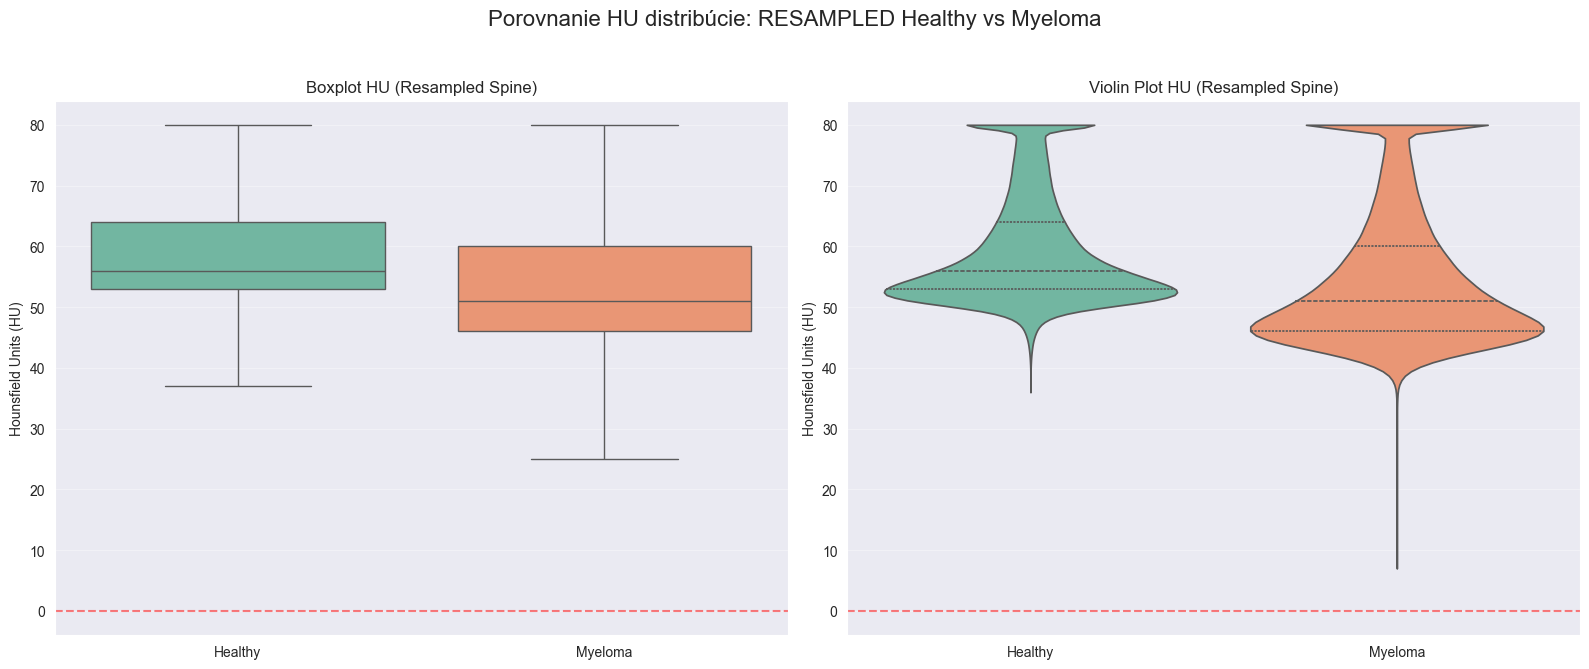

In [19]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Zoznamy na uloženie dát pre grafy
all_values = []
labels = []
p10_stats = []

### 1. NAČÍTANIE HEALTHY (Pôjde vľavo) ###
image_path_h = r"E:\DATA_Healthy_and_Myelom\Resampled\healthy_010_konv_resampled.nii.gz"
mask_path_h = r"E:\DATA_Healthy_and_Myelom\Resampled\healthy_010_spine_seg_resampled.nii.gz"

img_h = nib.load(image_path_h)
mask_h = nib.load(mask_path_h)
roi_values_h = img_h.get_fdata()[mask_h.get_fdata() > 0]

p10_h = np.percentile(roi_values_h, 10) if len(roi_values_h) > 0 else np.nan
print(f"HEALTHY -> Percentile10: {p10_h:.2f}")

all_values.append(roi_values_h)
labels.append("Healthy")
p10_stats.append(p10_h)


### 2. NAČÍTANIE MYELOMA (Pôjde vpravo) ###
image_path_mm = r"E:\DATA_Healthy_and_Myelom\Resampled\myel_001_konv_resampled.nii.gz"
mask_path_mm = r"E:\DATA_Healthy_and_Myelom\Resampled\myel_001_spine_seg_resampled.nii.gz"

img_mm = nib.load(image_path_mm)
mask_mm = nib.load(mask_path_mm)
roi_values_mm = img_mm.get_fdata()[mask_mm.get_fdata() > 0]

p10_mm = np.percentile(roi_values_mm, 10) if len(roi_values_mm) > 0 else np.nan
print(f"MM -> Percentile10: {p10_mm:.2f}")

all_values.append(roi_values_mm)
labels.append("Myeloma")
p10_stats.append(p10_mm)


# --- VIZUALIZÁCIA ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("darkgrid")

# 1. Boxplot
sns.boxplot(ax=ax1, data=all_values, showfliers=False, palette="Set2")
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels)
ax1.set_title('Boxplot HU (Resampled Spine)')
ax1.set_ylabel('Hounsfield Units (HU)')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)

# 2. Violin Plot
sns.violinplot(ax=ax2, data=all_values, inner="quartile", palette="Set2", cut=0)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_title('Violin Plot HU (Resampled Spine)')
ax2.set_ylabel('Hounsfield Units (HU)')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Porovnanie HU distribúcie: RESAMPLED Healthy vs Myeloma', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

HEALTHY -> Percentile10: 278.00
MM -> Percentile10: 98.00


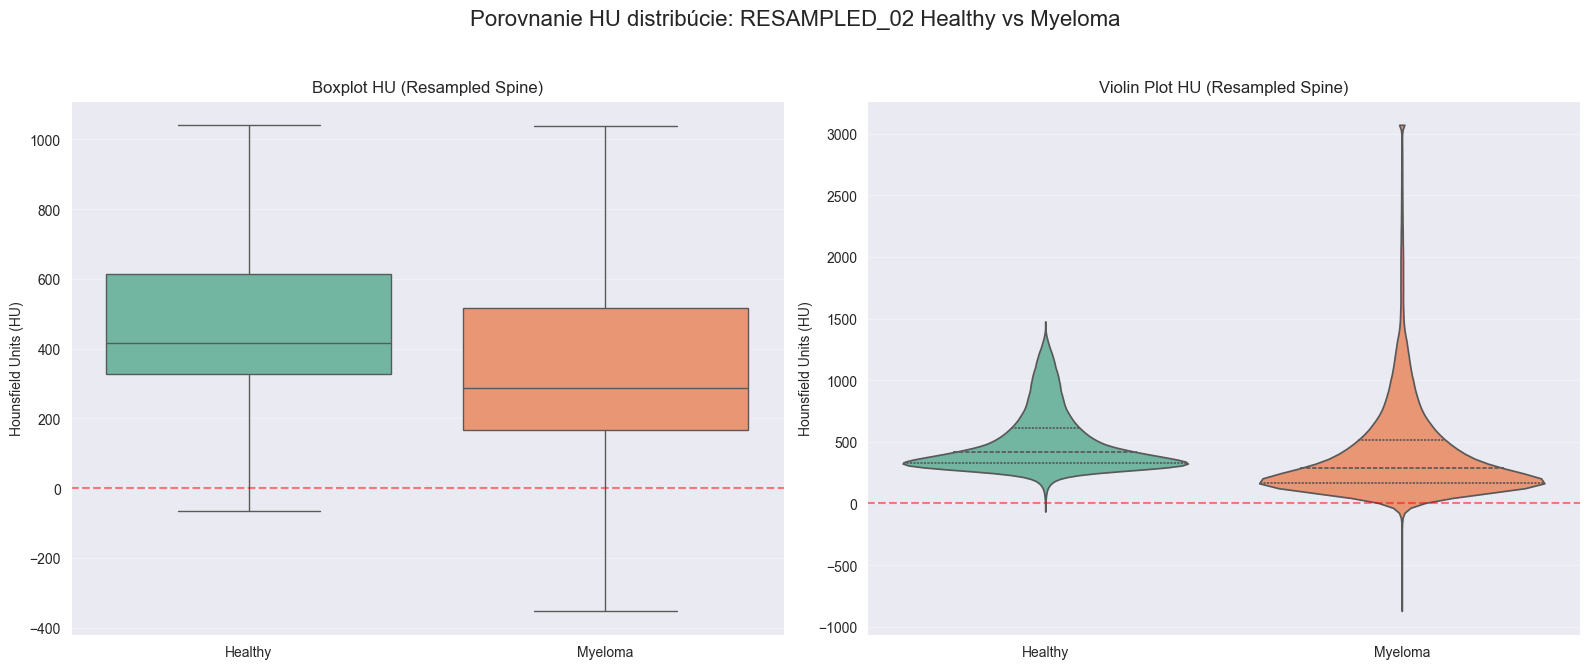

In [20]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Zoznamy na uloženie dát pre grafy
all_values = []
labels = []
p10_stats = []

### HEALTHY ###
image_path_h = r"E:\DATA_Healthy_and_Myelom\Resampled\healthy_010_konv_resampled_02.nii.gz"
mask_path_h = r"E:\DATA_Healthy_and_Myelom\Resampled\healthy_010_spine_seg_resampled_02.nii.gz"

img_h = nib.load(image_path_h)
mask_h = nib.load(mask_path_h)
roi_values_h = img_h.get_fdata()[mask_h.get_fdata() > 0]

p10_h = np.percentile(roi_values_h, 10) if len(roi_values_h) > 0 else np.nan
print(f"HEALTHY -> Percentile10: {p10_h:.2f}")

all_values.append(roi_values_h)
labels.append("Healthy")
p10_stats.append(p10_h)


### MYELOMA ###
image_path_mm = r"E:\DATA_Healthy_and_Myelom\Resampled\myel_001_konv_resampled_02.nii.gz"
mask_path_mm = r"E:\DATA_Healthy_and_Myelom\Resampled\myel_001_spine_seg_resampled_02.nii.gz"

img_mm = nib.load(image_path_mm)
mask_mm = nib.load(mask_path_mm)
roi_values_mm = img_mm.get_fdata()[mask_mm.get_fdata() > 0]

p10_mm = np.percentile(roi_values_mm, 10) if len(roi_values_mm) > 0 else np.nan
print(f"MM -> Percentile10: {p10_mm:.2f}")

all_values.append(roi_values_mm)
labels.append("Myeloma")
p10_stats.append(p10_mm)


# --- VIZUALIZÁCIA ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("darkgrid")

# 1. Boxplot
sns.boxplot(ax=ax1, data=all_values, showfliers=False, palette="Set2")
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels)
ax1.set_title('Boxplot HU (Resampled Spine)')
ax1.set_ylabel('Hounsfield Units (HU)')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)

# 2. Violin Plot
sns.violinplot(ax=ax2, data=all_values, inner="quartile", palette="Set2", cut=0)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_title('Violin Plot HU (Resampled Spine)')
ax2.set_ylabel('Hounsfield Units (HU)')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Porovnanie HU distribúcie: RESAMPLED_02 Healthy vs Myeloma', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Healthy percentile10 = -1011.0
Healthy percentile10 = -1024.0


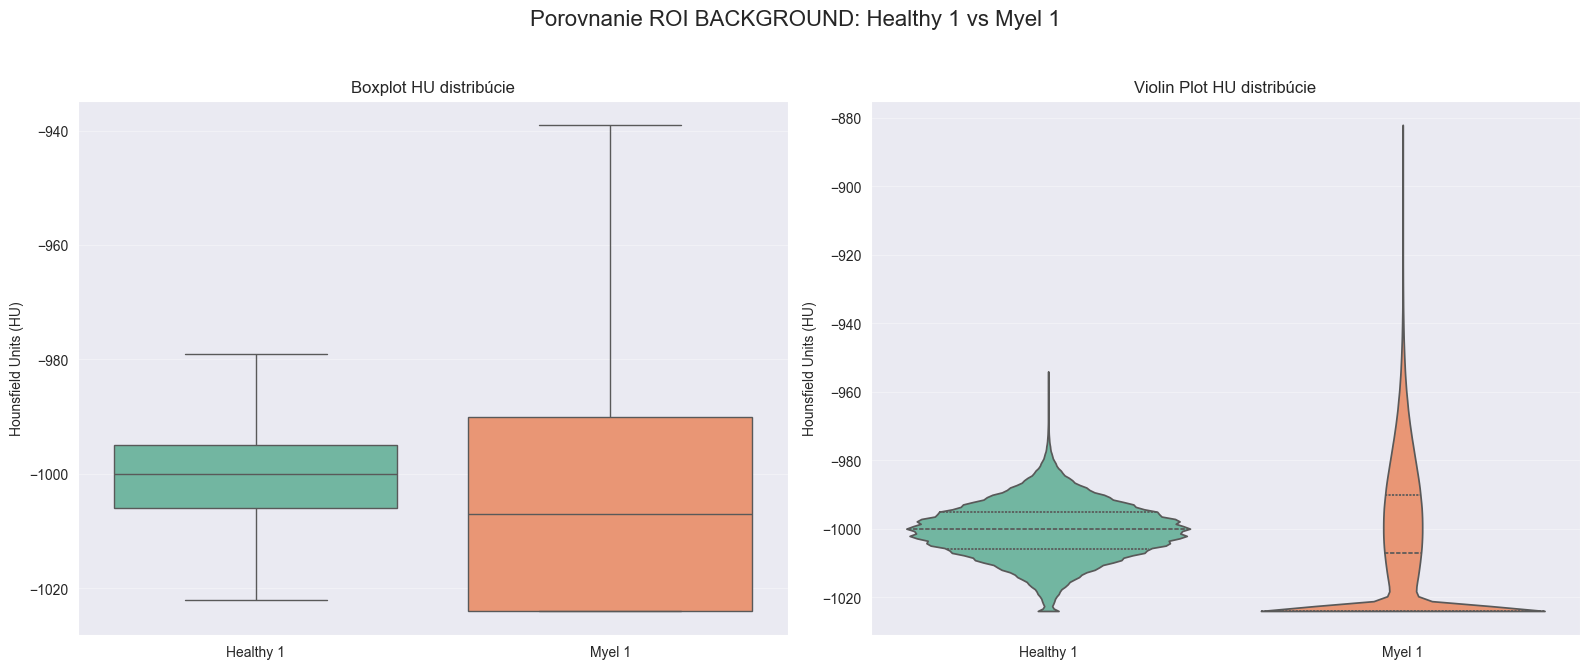

In [5]:
# COMPARE BACKGROUND

%matplotlib qt
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import time

def visualize_dual_sync(p1_cfg, p2_cfg):
    # 1. Načítanie oboch obrazov
    img1 = nib.load(p1_cfg['img']).get_fdata()
    img2 = nib.load(p2_cfg['img']).get_fdata()

    # Vytvorenie jednej figúry s dvoma podgrafmi (1 riadok, 2 stĺpce)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Nastavenie okna pre zobrazenie (Bone window pre spine)
    vmin, vmax = -200, 800

    # Určíme dĺžku animácie podľa toho, ktorý rozsah je kratší
    z_len1 = p1_cfg['z_range'][1] - p1_cfg['z_range'][0]
    z_len2 = p2_cfg['z_range'][1] - p2_cfg['z_range'][0]
    num_frames = min(z_len1, z_len2)

    plt.show(block=False)

    for i in range(num_frames):
        # Aktuálne indexy rezov pre každého pacienta
        z1 = p1_cfg['z_range'][0] + i
        z2 = p2_cfg['z_range'][0] + i

        # --- Pacient 1 (Vľavo) ---
        ax1.clear()
        ax1.imshow(img1[:, :, z1].T, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
        rect1 = plt.Rectangle((p1_cfg['x_range'][0], p1_cfg['y_range'][0]),
                              p1_cfg['x_range'][1]-p1_cfg['x_range'][0],
                              p1_cfg['y_range'][1]-p1_cfg['y_range'][0],
                              linewidth=2, edgecolor='green', facecolor='none')
        ax1.add_patch(rect1)
        ax1.set_title(f"{p1_cfg['label']} | Rez: {z1}")
        ax1.axis('on')

        # --- Pacient 2 (Vpravo) ---
        ax2.clear()
        ax2.imshow(img2[:, :, z2].T, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
        rect2 = plt.Rectangle((p2_cfg['x_range'][0], p2_cfg['y_range'][0]),
                              p2_cfg['x_range'][1]-p2_cfg['x_range'][0],
                              p2_cfg['y_range'][1]-p2_cfg['y_range'][0],
                              linewidth=2, edgecolor='red', facecolor='none')
        ax2.add_patch(rect2)
        ax2.set_title(f"{p2_cfg['label']} | Rez: {z2}")
        ax2.axis('on')

        # Prekreslenie spoločného okna
        fig.canvas.draw()
        fig.canvas.flush_events()
        time.sleep(0.05)

    plt.close(fig)

    # Extrakcia hodnôt pre boxplot (z celého 3D rozsahu)
    vals1 = img1[p1_cfg['x_range'][0]:p1_cfg['x_range'][1],
                 p1_cfg['y_range'][0]:p1_cfg['y_range'][1],
                 p1_cfg['z_range'][0]:p1_cfg['z_range'][1]].flatten()
    print(f"Healthy percentile10 = {np.percentile(vals1, 10)}")

    vals2 = img2[p2_cfg['x_range'][0]:p2_cfg['x_range'][1],
                 p2_cfg['y_range'][0]:p2_cfg['y_range'][1],
                 p2_cfg['z_range'][0]:p2_cfg['z_range'][1]].flatten()
    print(f"Healthy percentile10 = {np.percentile(vals2, 10)}")

    return vals1, vals2

# --- KONFIGURÁCIA ---
p1_config = {
    "img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_001\healthy_001_konv.nii.gz",
    "label": "Healthy 1",
    "x_range": (100, 200), "y_range": (400, 500), "z_range": (100, 300)
}

p2_config = {
    "img": r"E:\DATA_Myelomy\Myel_001\myel_001_konv.nii.gz",
    "label": "Myel 1",
    "x_range": (100, 300), "y_range": (460, 500), "z_range": (550, 750)
}

# Spustenie vizualizácie (otvorí QT/TK okno s videom)
v1, v2 = visualize_dual_sync(p1_config, p2_config)

# --- FINÁLNA VIZUALIZÁCIA (Boxplot + Violin Plot) ---
import seaborn as sns
import numpy as np

sns.set_style("darkgrid")
# Prepnutie späť do notebooku
%matplotlib inline

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
labels = [p1_config['label'], p2_config['label']]
all_data = [v1, v2]

# 1. BOXPLOT
sns.boxplot(ax=ax1, data=all_data, showfliers=False, palette="Set2")
ax1.set_xticks([0, 1])
ax1.set_xticklabels(labels)
ax1.set_ylabel('Hounsfield Units (HU)')
ax1.set_title('Boxplot HU distribúcie')
# ax1.axhline(0, color='red', linestyle='--', alpha=0.5)

# 2. VIOLIN PLOT
sns.violinplot(ax=ax2, data=all_data, inner="quartile", palette="Set2", cut=0)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(labels)
ax2.set_ylabel('Hounsfield Units (HU)')
ax2.set_title('Violin Plot HU distribúcie')
# ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle(f'Porovnanie ROI BACKGROUND: {p1_config["label"]} vs {p2_config["label"]}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

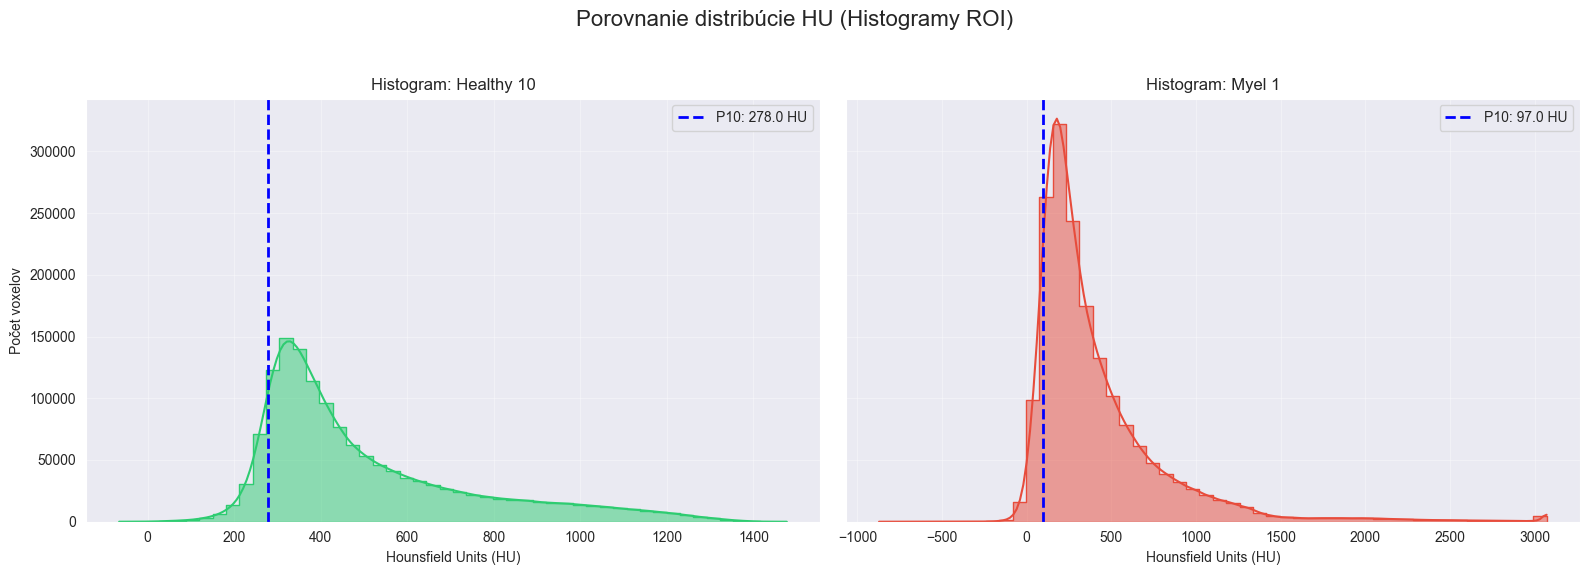

In [6]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

def get_roi_values(img_path, mask_path):
    img = nib.load(img_path)
    mask = nib.load(mask_path)
    img_data = img.get_fdata()
    mask_data = mask.get_fdata()
    roi_values = img_data[mask_data > 0]
    return roi_values

# Konfigurácia ciest
data_config = [
    {"img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_konv.nii.gz",
     "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_spine_seg.nii.gz",
     "label": "Healthy 10", "color": "#2ecc71"},
    {"img": r"E:\DATA_Myelomy\Myel_001\myel_001_konv.nii.gz",
     "mask": r"E:\DATA_Myelomy\Myel_001\myel_001_spine_seg.nii.gz",
     "label": "Myel 1", "color": "#e74c3c"}
]

# --- VIZUALIZÁCIA (Histogramy vedľa seba) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
sns.set_style("darkgrid")

for i, p in enumerate(data_config):
    values = get_roi_values(p['img'], p['mask'])
    p10 = np.percentile(values, 10)

    # Vykreslenie histogramu
    sns.histplot(values, bins=50, ax=axes[i], color=p['color'], kde=True, element="step")

    # Pridanie vertikálnej čiary pre Percentile 10
    axes[i].axvline(p10, color='blue', linestyle='--', linewidth=2, label=f'P10: {p10:.1f} HU')

    # Formátovanie jednotlivých podgrafov
    axes[i].set_title(f"Histogram: {p['label']}")
    axes[i].set_xlabel('Hounsfield Units (HU)')
    axes[i].set_ylabel('Počet voxelov')
    axes[i].legend()

plt.suptitle('Porovnanie distribúcie HU (Histogramy ROI)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [10]:
# Odprahovať voxely len na základe príznaku percentile10 a pozrieť na výsledok -> aj healthy aj MM
import numpy as np
import nibabel as nib
import os

def create_p10_mask(img_path, mask_path):
    # 1. Načítanie dát
    img_obj = nib.load(img_path)
    img_data = img_obj.get_fdata()

    mask_obj = nib.load(mask_path)
    mask_data = mask_obj.get_fdata()

    # 2. Výpočet P10 prahu z pôvodnej ROI
    roi_values = img_data[mask_data > 0]
    p10_threshold = np.percentile(roi_values, 5)

    # 3. Odprahovanie: Ponecháme len voxely v maske, ktoré sú pod P10
    p10_mask_data = np.zeros_like(img_data)
    p10_mask_data[(mask_data > 0) & (img_data < p10_threshold)] = 1

    # 4. Uloženie novej masky
    # Získame cestu k priečinku, kde je pôvodný obraz
    directory = os.path.dirname(img_path)
    output_path = os.path.join(directory, "p5_segmented_mask_vmi40.nii.gz")

    # Vytvorenie NIfTI objektu (použijeme affine z pôvodného obrazu pre správnu orientáciu)
    new_mask_img = nib.Nifti1Image(p10_mask_data.astype(np.float32), img_obj.affine, img_obj.header)
    nib.save(new_mask_img, output_path)

    print(f"Uložené: {output_path} (Prah: {p10_threshold:.2f} HU)")

# Konfigurácia (uprav cesty ak je treba)
data_config = [
    {
        "img": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_monoe_40kev.nii.gz",
        "mask": r"E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\healthy_010_spine_seg.nii.gz"
    },
    {
        "img": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_001\myel_001_monoe_40kev.nii.gz",
        "mask": r"E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_001\myel_001_spine_seg.nii.gz"
    }
]

# Spustenie procesu
for p in data_config:
    create_p10_mask(p['img'], p['mask'])

Uložené: E:\DATA_Healthy_and_Myelom\DATA_Healthy\Healthy_010\p5_segmented_mask_vmi40.nii.gz (Prah: 574.00 HU)
Uložené: E:\DATA_Healthy_and_Myelom\DATA_MM_Stage1\Myel_001\p5_segmented_mask_vmi40.nii.gz (Prah: 201.00 HU)
